In [191]:
import numpy as np
from scipy import signal as sg
import matplotlib
import matplotlib.pyplot as plt

![](spec.png)

0.8912509381337456 0.01
Saved spec_plot.png


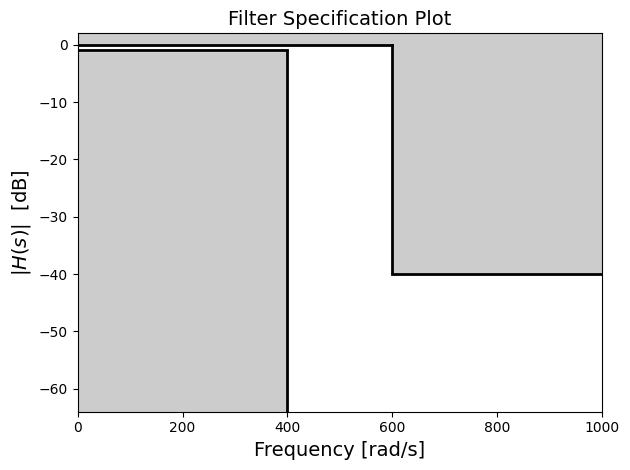

In [192]:
# Spec visualization
passband_ripple = pow(10, (-1/20))
stopband_ripple = pow(10, (-2))
wp = 400
ws = 600
gpass = 1
gstop = 40

print(passband_ripple, stopband_ripple)


figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Filter Specification Plot', fontsize=14)


# Passband restriction
ax.axhline(y=0, xmin=0, xmax=0.6, color='black', lw=2)
ax.axhline(y=-passband_ripple, xmin=0, xmax=0.4, color='black', lw=2)

# Transition band restriction
ax.axvline(x=400, ymax= 0.985 - (3-passband_ripple) / 66, color='black', lw=2)
ax.axvline(x=600, ymin= 0.975 - gstop / 66, ymax= 1 - (3-passband_ripple) / 66, color='black', lw=2)

# Stopband restriction
ax.axhline(y=-gstop, xmin=0.6, xmax=1, color='black', lw=2)

ax.set_xlabel(r'Frequency [rad/s]', fontsize=14)
ax.set_xlim(0, 1000)

ax.set_ylabel(r'$|H(s)|$  [dB]', fontsize=14)
ax.set_ylim(ymin=-64, ymax=2)

# Shading
w = np.linspace(0,1000,1000)
ax.fill_between(w, -64, where = w < wp, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, 2, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, -gstop, where = w > ws, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, -gpass, where = w < wp, color='white', alpha=1, zorder=1)

plt.tight_layout()
plt.savefig('spec_plot.png', dpi=200, bbox_inches='tight')
print("Saved spec_plot.png")

In [193]:
# Find required order
ord_bw, wn_bw = sg.buttord(wp=wp, ws=ws, gpass=gpass, gstop=gstop, analog=True)
ord_chI, wn_chI = sg.cheb1ord(wp=wp, ws=ws, gpass=gpass, gstop=gstop, analog=True)
ord_chII, wn_chII = sg.cheb2ord(wp=wp, ws=ws, gpass=gpass, gstop=gstop, analog=True)
ord_ell, wn_ell = sg.ellipord(wp=wp, ws=ws, gpass=gpass, gstop=gstop, analog=True)

print(ord_bw, ord_chI, ord_chII, ord_ell)

14 7 7 5


In [194]:
# Design filters
bw_z, bw_p, bw_k = sg.butter(N=ord_bw, Wn=wn_bw, analog=True, output='zpk')
chI_z, chI_p, chI_k = sg.cheby1(N=ord_chI, Wn=wn_chI, analog=True, output='zpk', rp=1)
chII_z, chII_p, chII_k = sg.cheby2(N=ord_chII, Wn=wn_chII, analog=True, output='zpk', rs=40)
ell_z, ell_p, ell_k = sg.ellip(N=ord_ell, Wn=wn_ell, analog=True, output='zpk', rp=1, rs=40)
bess_z, bess_p, bess_k = sg.bessel(N=ord_bw, Wn=wn_bw, analog=True, output='zpk')

In [195]:
# Magnitude Responses
bw_w, bw_resp = sg.freqs_zpk(z=bw_z, p=bw_p, k=bw_k, worN=np.linspace(0,1200,1200))
chI_w, chI_resp = sg.freqs_zpk(z=chI_z, p=chI_p, k=chI_k, worN=np.linspace(0,1200,1200))
chII_w, chII_resp = sg.freqs_zpk(z=chII_z, p=chII_p, k=chII_k, worN=np.linspace(0,1200,1200))
ell_w, ell_resp = sg.freqs_zpk(z=ell_z, p=ell_p, k=ell_k, worN=np.linspace(0,1200,1200))
bess_w, bess_resp = sg.freqs_zpk(z=bess_z, p=bess_p, k=bess_k, worN=np.linspace(0,1200,1200))

bw_mag = 20 * np.log10(abs(bw_resp))
chI_mag = 20 * np.log10(abs(chI_resp))
chII_mag = 20 * np.log10(abs(chII_resp))
ell_mag = 20 * np.log10(abs(ell_resp))
bess_mag = 20 * np.log10(abs(bess_resp))

bw_phase = np.angle(bw_resp)
chI_phase = np.angle(chI_resp)
chII_phase = np.angle(chII_resp)
ell_phase = np.angle(ell_resp)
bess_phase = np.angle(bess_resp)

bw_group_delay = -np.diff(np.unwrap(bw_phase)) / np.diff(bw_w)
chI_group_delay = -np.diff(np.unwrap(chI_phase)) / np.diff(chI_w)
chII_group_delay = -np.diff(np.unwrap(chII_phase)) / np.diff(chII_w)
ell_group_delay = -np.diff(np.unwrap(ell_phase)) / np.diff(ell_w)
bess_group_delay = -np.diff(np.unwrap(bess_phase)) / np.diff(bess_w)

for i in range(1, len(bw_group_delay) - 1):
    if bw_group_delay[i] < -1:
        bw_group_delay[i] = (bw_group_delay[i + 1] + bw_group_delay[i - 1]) / 2
    if chI_group_delay[i] < -1:
        chI_group_delay[i] = (chI_group_delay[i + 1] + chI_group_delay[i - 1]) / 2
    if chII_group_delay[i] < -1:
        chII_group_delay[i] = (chII_group_delay[i + 1] + chII_group_delay[i - 1]) / 2
    if ell_group_delay[i] < -1:
        ell_group_delay[i] = (ell_group_delay[i + 1] + ell_group_delay[i - 1]) / 2
    if bess_group_delay[i] < -1:
        bess_group_delay[i] = (bess_group_delay[i + 1] + bess_group_delay[i - 1]) / 2

Saved mag_response.png


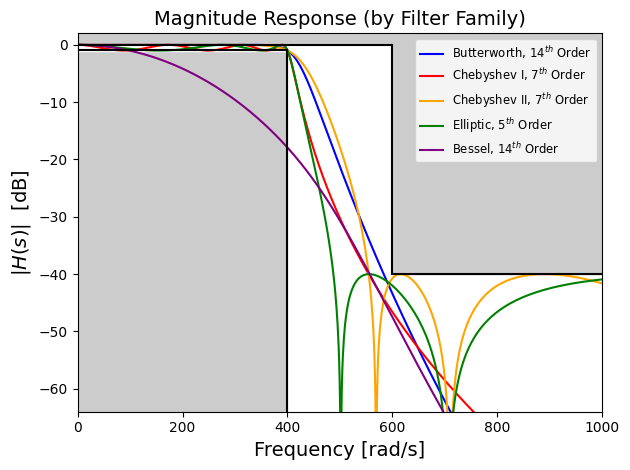

In [196]:
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Magnitude Response (by Filter Family)', fontsize=14)

# Passband restriction
ax.axhline(y=0, xmin=0, xmax=0.6, color='black', lw=1.5, zorder=3)
ax.axhline(y=-passband_ripple, xmin=0, xmax=0.4, color='black', lw=1.5, zorder=3)

# Transition band restriction
ax.axvline(x=400, ymax= 0.985 - (3-passband_ripple) / 66, color='black', lw=1.5, zorder=3)
ax.axvline(x=600, ymin= 0.975 - gstop / 66, ymax= 1 - (3-passband_ripple) / 66, color='black', lw=1.5, zorder=3)

# Stopband restriction
ax.axhline(y=-gstop, xmin=0.6, xmax=1, color='black', lw=1.5, zorder=3)

ax.set_xlabel(r'Frequency [rad/s]', fontsize=14)
ax.set_xlim(0, 1000)

ax.set_ylabel(r'$|H(s)|$  [dB]', fontsize=14)
ax.set_ylim(ymin=-64, ymax=2)


# Butterworth
ax.plot(bw_w, bw_mag, color='blue', label="Butterworth, $14^{th}$ Order", zorder=2)
ax.plot(chI_w, chI_mag, color='red', label="Chebyshev I, $7^{th}$ Order", zorder=2)
ax.plot(chII_w, chII_mag, color='orange', label="Chebyshev II, $7^{th}$ Order", zorder=2)
ax.plot(ell_w, ell_mag, color='green', label="Elliptic, $5^{th}$ Order", zorder=2)
ax.plot(bess_w, bess_mag, color='purple', label="Bessel, $14^{th}$ Order", zorder=2)

# Shading
w = np.linspace(0,1200,1200)
ax.fill_between(w, -64, where = w < wp, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, 2, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, -gstop, where = w > ws, color='0.8', alpha=1, zorder=0)
ax.fill_between(w, -gpass, where = w < wp, color='white', alpha=1, zorder=1)

plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.savefig('mag_response.png', dpi=200, bbox_inches='tight')
print("Saved mag_response.png")

Saved zeros_poles.png


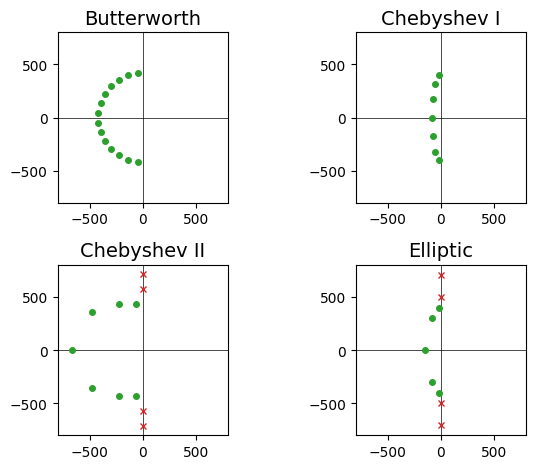

In [197]:
figure = plt.figure()

ax1 = figure.add_subplot(2, 2, 1)
ax1.set_title(r'Butterworth', fontsize=14)
ax1.plot(np.real(bw_z), np.imag(bw_z), 'x', color='C3', ms=5, zorder=2)
ax1.plot(np.real(bw_p), np.imag(bw_p), 'o', color='C2', ms=4, zorder=2)
ax1.axhline(color='0', lw=0.5, zorder=0)
ax1.axvline(color='0', lw=0.5, zorder=0)
ax1.set_xlim(-800, 800)
ax1.set_ylim(-800, 800)

plt.gca().set_aspect('equal')

ax2 = figure.add_subplot(2, 2, 2)
ax2.set_title(r'Chebyshev I', fontsize=14)
ax2.plot(np.real(chI_z), np.imag(chI_z), 'x', color='C3', ms=5, zorder=2)
ax2.plot(np.real(chI_p), np.imag(chI_p), 'o', color='C2', ms=4, zorder=2)
ax2.axhline(color='0', lw=0.5, zorder=0)
ax2.axvline(color='0', lw=0.5, zorder=0)
ax2.set_xlim(-800, 800)
ax2.set_ylim(-800, 800)

plt.gca().set_aspect('equal')

ax3 = figure.add_subplot(2, 2, 3)
ax3.set_title(r'Chebyshev II', fontsize=14)
ax3.plot(np.real(chII_z), np.imag(chII_z), 'x', color='C3', ms=5, zorder=2)
ax3.plot(np.real(chII_p), np.imag(chII_p), 'o', color='C2', ms=4, zorder=2)
ax3.axhline(color='0', lw=0.5, zorder=0)
ax3.axvline(color='0', lw=0.5, zorder=0)
ax3.set_xlim(-800, 800)
ax3.set_ylim(-800, 800)

plt.gca().set_aspect('equal')

ax4 = figure.add_subplot(2, 2, 4)
ax4.set_title(r'Elliptic', fontsize=14)
ax4.plot(np.real(ell_z), np.imag(ell_z), 'x', color='C3', ms=5, zorder=2)
ax4.plot(np.real(ell_p), np.imag(ell_p), 'o', color='C2', ms=4, zorder=2)
ax4.axhline(color='0', lw=0.5, zorder=0)
ax4.axvline(color='0', lw=0.5, zorder=0)
ax4.set_xlim(-800, 800)
ax4.set_ylim(-800, 800)


plt.gca().set_aspect('equal')

plt.tight_layout()
plt.savefig('zeros_poles.png', dpi=200, bbox_inches='tight')
print("Saved zeros_poles.png")

Saved phase_response.png


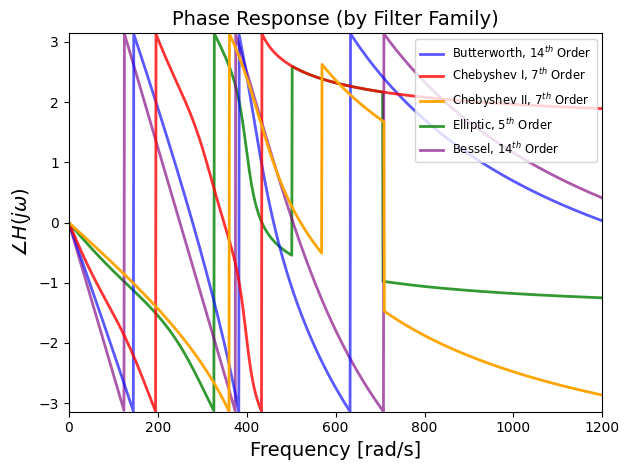

In [198]:
# Phase plot
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Phase Response (by Filter Family)', fontsize=14)

ax.set_xlabel(r'Frequency [rad/s]', fontsize=14)
ax.set_xlim(0, 1200)

ax.set_ylabel(r'$∠H(j\omega)$', fontsize=14)
ax.set_ylim(ymin=-np.pi, ymax=np.pi)

# Filters
ax.plot(bw_w, bw_phase, color='blue', label="Butterworth, $14^{th}$ Order", zorder=2, alpha=0.65, lw=2)
ax.plot(chI_w, chI_phase, color='red', label="Chebyshev I, $7^{th}$ Order", zorder=2, alpha=0.8, lw=2)
ax.plot(chII_w, chII_phase, color='orange', label="Chebyshev II, $7^{th}$ Order", zorder=2, alpha=1, lw=2)
ax.plot(ell_w, ell_phase, color='green', label="Elliptic, $5^{th}$ Order", zorder=1, alpha=0.8, lw=2)
ax.plot(bess_w, bess_phase, color='purple', label="Bessel, $14^{th}$ Order", zorder=1, alpha=0.65, lw=2)


plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.savefig('phase_response.png', dpi=200, bbox_inches='tight')
print("Saved phase_response.png")

Saved group_delay.png


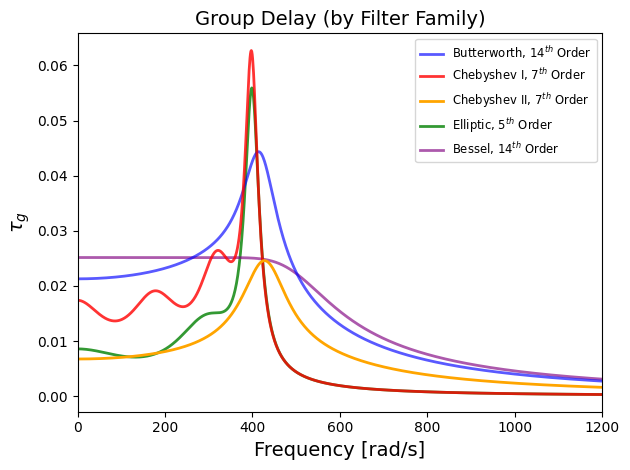

In [199]:
# Group delay plot
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Group Delay (by Filter Family)', fontsize=14)

ax.set_xlabel(r'Frequency [rad/s]', fontsize=14)
ax.set_xlim(0, 1200)

ax.set_ylabel(r'$\tau_g$', fontsize=14)
# Filters
ax.plot(np.linspace(0, len(bw_group_delay), len(bw_group_delay)), bw_group_delay, color='blue', label="Butterworth, $14^{th}$ Order", zorder=2, alpha=0.65, lw=2)
ax.plot(np.linspace(0, len(chI_group_delay), len(chI_group_delay)), chI_group_delay, color='red', label="Chebyshev I, $7^{th}$ Order", zorder=2, alpha=0.8, lw=2)
ax.plot(np.linspace(0, len(chII_group_delay), len(chII_group_delay)), chII_group_delay, color='orange', label="Chebyshev II, $7^{th}$ Order", zorder=2, alpha=1, lw=2)
ax.plot(np.linspace(0, len(ell_group_delay), len(ell_group_delay)), ell_group_delay, color='green', label="Elliptic, $5^{th}$ Order", zorder=1, alpha=0.8, lw=2)
ax.plot(np.linspace(0, len(bess_group_delay), len(bess_group_delay)), bess_group_delay, color='purple', label="Bessel, $14^{th}$ Order", zorder=1, alpha=0.65, lw=2)


plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.savefig('group_delay.png', dpi=200, bbox_inches='tight')
print("Saved group_delay.png")

In [200]:
bw_t, bw_impulse = sg.impulse([bw_z, bw_p, bw_k])
chI_t, chI_impulse = sg.impulse([chI_z, bw_p, bw_k])
chII_t, chII_impulse = sg.impulse([chII_z, chII_p, chII_k])
ell_t, ell_impulse = sg.impulse([ell_z, ell_p, ell_k])


t = np.linspace(start=0, stop=0.2, num=100)
max = t[len(t) - 1]

print(max)

0.2


Saved impulse.png


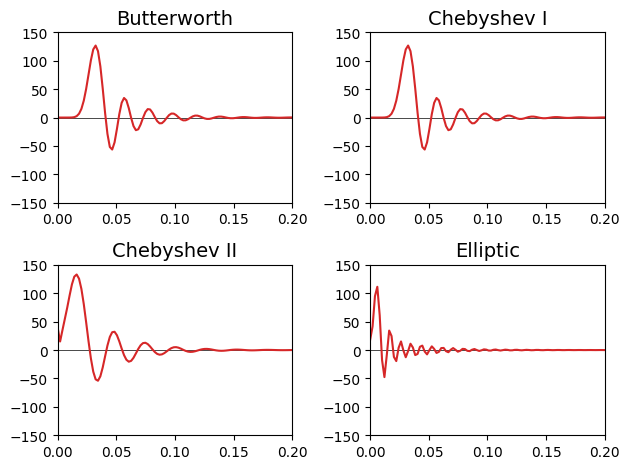

In [201]:
figure = plt.figure()

ax1 = figure.add_subplot(2, 2, 1)
ax1.set_title(r'Butterworth', fontsize=14)
ax1.plot(t, bw_impulse, color='C3', ms=5, zorder=2)
ax1.axhline(color='0', lw=0.5, zorder=0)
ax1.axvline(color='0', lw=0.5, zorder=0)
ax1.set_xlim(0, max)
ax1.set_ylim(-150, 150)

ax2 = figure.add_subplot(2, 2, 2)
ax2.set_title(r'Chebyshev I', fontsize=14)
ax2.plot(t, chI_impulse, color='C3', ms=5, zorder=2)
ax2.axhline(color='0', lw=0.5, zorder=0)
ax2.axvline(color='0', lw=0.5, zorder=0)
ax2.set_xlim(0, max)
ax2.set_ylim(-150, 150)

ax3 = figure.add_subplot(2, 2, 3)
ax3.set_title(r'Chebyshev II', fontsize=14)
ax3.plot(t, chII_impulse, color='C3', ms=5, zorder=2)
ax3.axhline(color='0', lw=0.5, zorder=0)
ax3.axvline(color='0', lw=0.5, zorder=0)
ax3.set_xlim(0, max)
ax3.set_ylim(-150, 150)

ax4 = figure.add_subplot(2, 2, 4)
ax4.set_title(r'Elliptic', fontsize=14)
ax4.plot(t, ell_impulse, color='C3', ms=5, zorder=2)
ax4.axhline(color='0', lw=0.5, zorder=0)
ax4.axvline(color='0', lw=0.5, zorder=0)
ax4.set_xlim(0, max)
ax4.set_ylim(-150, 150)

plt.tight_layout()
plt.savefig('impulse.png', dpi=200, bbox_inches='tight')
print("Saved impulse.png")

Specification: passband $350 ≤ ω ≤ 650$ rad/s with ripple $≤ 1$ dB, and stopbands at $ω ≤ 250$ rad/s and $ω ≥ 750$ rad/s with attenuation $≥ 40$ dB.

In [202]:
# Spec visualization
wp_r = 650
ws_r = 750
wp_l = 350
ws_l = 250
gpass = 1
gstop = 40

ord_bp, wn_bp = sg.cheb1ord(wp=[wp_l, wp_r], ws=[ws_l, ws_r], gpass=gpass, gstop=gstop, analog=True)

bp_z, bp_p, bp_k = sg.cheby1(N=ord_bp, rp=gpass, Wn = wn_bp, btype='bandpass', analog='True', output='zpk')
bp_w, bp_resp = sg.freqs_zpk(z=bp_z, p=bp_p, k=bp_k, worN=np.linspace(0,1000,1000))
bp_mag = 20 * np.log10(abs(bp_resp))
bp_phase = np.angle(bp_resp)
bp_group_delay = -np.diff(np.unwrap(bp_phase)) / np.diff(bp_w)

C:\Users\aidan\AppData\Local\Temp\ipykernel_35544\1895015762.py:13: RuntimeWarning: divide by zero encountered in log10
  bp_mag = 20 * np.log10(abs(bp_resp))


Saved mag_bp.png


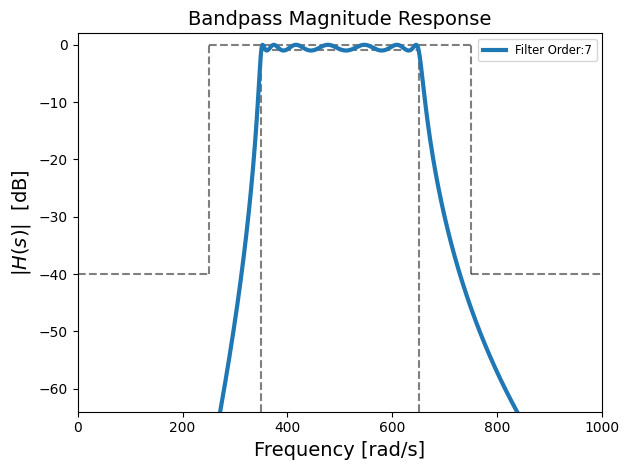

In [203]:
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Bandpass Magnitude Response', fontsize=14)

# Passband restrictions
ax.axhline(y=0, xmin=(ws_l / 1000), xmax=(ws_r / 1000), color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)
ax.axhline(y=-passband_ripple, xmin=(wp_l / 1000), xmax=(wp_r / 1000), color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)

# Transition band restriction
ax.axvline(x=ws_l, ymin=(66-40-2)/66, ymax=32/33, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)
ax.axvline(x=ws_r, ymin=(66-40-2)/66, ymax=32/33, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)

ax.axvline(x=wp_l, ymin=0, ymax=(64 - passband_ripple) / 66, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)
ax.axvline(x=wp_r, ymin=0, ymax=(64 - passband_ripple) / 66, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)

# Stopband restrictions
ax.axhline(y=-gstop, xmin=(ws_r / 1000), xmax=1, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)
ax.axhline(y=-gstop, xmin=0, xmax=(ws_l / 1000), color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)

ax.set_xlabel(r'Frequency [rad/s]', fontsize=14)
ax.set_xlim(0, 1000)

ax.set_ylabel(r'$|H(s)|$  [dB]', fontsize=14)
ax.set_ylim(ymin=-64, ymax=2)

ax.plot(bp_w, bp_mag, zorder=5, lw=3, label=("".join(["Filter Order:", str(ord_bp)])))

plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.savefig('mag_bp.png', dpi=200, bbox_inches='tight')
print("Saved mag_bp.png")

In [204]:
# Spec visualization
wp = 480
ws = 520
gpass = 1
gstop = 40

ord_lp, wn_lp = sg.buttord(wp=wp, ws=ws, gpass=gpass, gstop=gstop, analog=True)

print(ord_lp, wn_lp)

lp_b, lp_a = sg.butter(N=ord_lp, Wn = wn_lp, btype='lowpass', analog='True', output='ba')

lp_w, lp_resp = sg.freqs(b=lp_b, a=lp_a, worN=np.linspace(0,1000,1000))
lp_mag = 20 * np.log10(abs(lp_resp))
lp_phase = np.angle(lp_resp)
lp_group_delay = -np.diff(np.unwrap(lp_phase)) / np.diff(lp_w)

66 484.9387445305552


Saved high_order_mag_ba.png


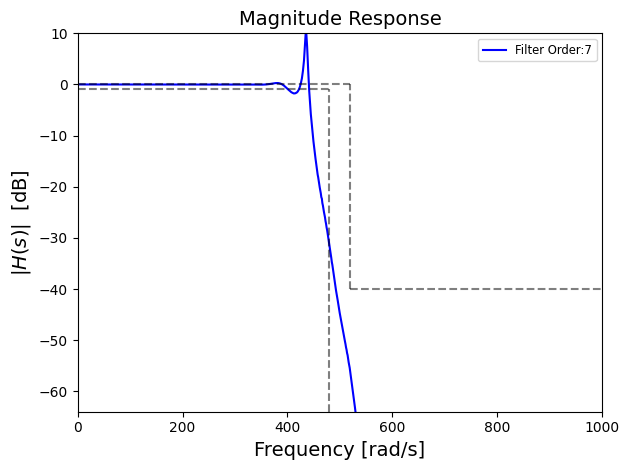

In [205]:
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Magnitude Response', fontsize=14)

# Passband restriction
ax.axhline(y=0, xmin=0, xmax=(ws / 1000), color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)
ax.axhline(y=-passband_ripple, xmin=0, xmax=(wp / 1000), color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)

# Transition band restriction
ax.axvline(x=wp, ymin=0, ymax=(64 - passband_ripple) / 74, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)
ax.axvline(x=ws, ymin=(74-40-10)/74, ymax=32/37, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)

# Stopband restriction
ax.axhline(y=-gstop, xmin=(ws / 1000), xmax=1, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)

ax.set_xlabel(r'Frequency [rad/s]', fontsize=14)
ax.set_xlim(0, 1000)

ax.set_ylabel(r'$|H(s)|$  [dB]', fontsize=14)
ax.set_ylim(ymin=-64, ymax=10)


# Butterworth
ax.plot(lp_w, lp_mag, color='blue', zorder=2, label=("".join(["Filter Order:", str(ord_bp)])))

plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.savefig('high_order_mag_ba.png', dpi=200, bbox_inches='tight')
print("Saved high_order_mag_ba.png")

In [206]:
lp_z, lp_p, lp_k = sg.butter(N=ord_lp, Wn = wn_lp, btype='lowpass', analog='True', output='zpk')

lp_w_zpk, lp_resp_zpk = sg.freqs_zpk(z=lp_z, p=lp_p, k=lp_k, worN=np.linspace(0,1000,1000))
lp_mag_zpk = 20 * np.log10(abs(lp_resp_zpk))
lp_phase_zpk = np.angle(lp_resp_zpk)
lp_group_delay_zpk = -np.diff(np.unwrap(lp_phase_zpk)) / np.diff(lp_w_zpk)

Saved high_order_mag_zpk.png


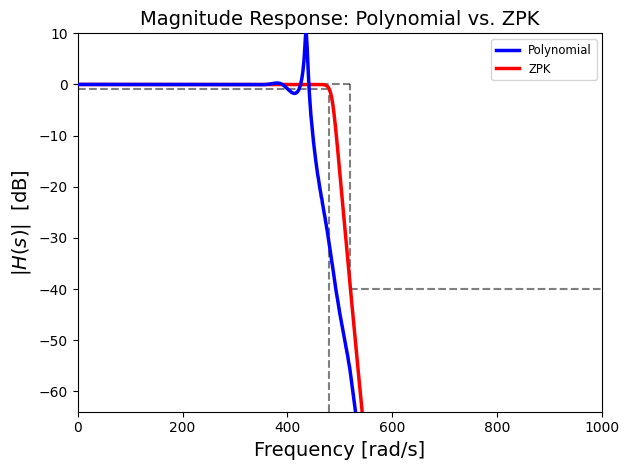

In [207]:
figure = plt.figure()
ax = figure.add_subplot(1, 1, 1)
ax.set_title(r'Magnitude Response: Polynomial vs. ZPK', fontsize=14)

# Passband restriction
ax.axhline(y=0, xmin=0, xmax=(ws / 1000), color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)
ax.axhline(y=-passband_ripple, xmin=0, xmax=(wp / 1000), color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)

# Transition band restriction
ax.axvline(x=wp, ymin=0, ymax=(64 - passband_ripple) / 74, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)
ax.axvline(x=ws, ymin=(74-40-10)/74, ymax=32/37, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)

# Stopband restriction
ax.axhline(y=-gstop, xmin=(ws / 1000), xmax=1, color='black', lw=1.5, zorder=3, linestyle="dashed", alpha=0.5)

ax.set_xlabel(r'Frequency [rad/s]', fontsize=14)
ax.set_xlim(0, 1000)

ax.set_ylabel(r'$|H(s)|$  [dB]', fontsize=14)
ax.set_ylim(ymin=-64, ymax=10)


# Butterworth
ax.plot(lp_w, lp_mag, color='blue', zorder=5, label="Polynomial", lw=2.5)
ax.plot(lp_w_zpk, lp_mag_zpk, color='red', zorder=4, label="ZPK", lw=2.5)

plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.savefig('high_order_mag_zpk.png', dpi=200, bbox_inches='tight')
print("Saved high_order_mag_zpk.png")